--- At Base Temperature T_C = 130 mK ---
Lorentzian Heat Leak (Q_B): 0.255 fW
Electron-Phonon Heat Leak (Q_ep): 0.068 fW
Total Heat Leak (Req. Cooling Power): 0.323 fW


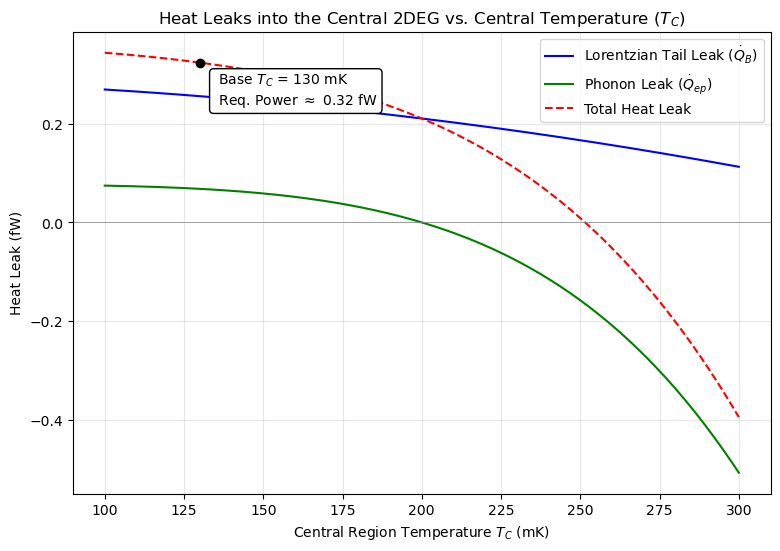

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Physical Constants ---
k_B = 1.380649e-23   # Boltzmann constant (J/K)
e = 1.602176634e-19  # Elementary charge (C)
L_0 = (k_B**2 * np.pi**2) / (3 * e**2) # Lorenz number (~2.44e-8 W*Ohm/K^2)

# --- 2. Device Parameters (from Fig. 4 text & caption) ---
T_E = 0.300          # Ambient electron temperature (K)
T_L = 0.200          # Lattice temperature (K)
V_SD = 75e-6         # Source-Drain bias (V)
V = V_SD / 2.0       # Voltage drop across ONE barrier (V)
G_B = 80e-9          # Background conductance of barriers (S)
A = 6.0              # Area of central 2DEG (um^2)
sigma = 40e-15       # Electron-phonon coupling (W / um^2 / K^5)

# --- 3. Heat Leak Equations ---
def q_lorentzian_leak(T_C, T_E, V, G_B):
    """Heat entering the central region through the Lorentzian tails."""
    T_bar = (T_E + T_C) / 2.0
    delta_T = T_C - T_E
    return -2 * G_B * (L_0 * T_bar * delta_T - (V**2) / 2.0)

def q_phonon_leak(T_C, T_L, A, sigma):
    """Heat entering the central region from the lattice (phonons)."""
    return A * sigma * (T_L**5 - T_C**5)

# --- 4. Simulation ---
# Evaluate the heat leaks for central temperatures between 100 mK and 300 mK
T_C_array = np.linspace(0.100, 0.300, 200)

Q_B_array = q_lorentzian_leak(T_C_array, T_E, V, G_B)
Q_ep_array = q_phonon_leak(T_C_array, T_L, A, sigma)
Q_total_array = Q_B_array + Q_ep_array

# Calculate specifically for the base temperature reported in Fig 4a/b (130 mK)
T_C_base = 0.130 
Q_B_base = q_lorentzian_leak(T_C_base, T_E, V, G_B)
Q_ep_base = q_phonon_leak(T_C_base, T_L, A, sigma)
Q_total_base = Q_B_base + Q_ep_base

print(f"--- At Base Temperature T_C = {T_C_base*1000:.0f} mK ---")
print(f"Lorentzian Heat Leak (Q_B): {Q_B_base*1e15:.3f} fW")
print(f"Electron-Phonon Heat Leak (Q_ep): {Q_ep_base*1e15:.3f} fW")
print(f"Total Heat Leak (Req. Cooling Power): {Q_total_base*1e15:.3f} fW")

# --- 5. Plotting ---
plt.figure(figsize=(9, 6))
plt.plot(T_C_array * 1000, Q_B_array * 1e15, label='Lorentzian Tail Leak ($\dot{Q}_B$)', color='blue')
plt.plot(T_C_array * 1000, Q_ep_array * 1e15, label='Phonon Leak ($\dot{Q}_{ep}$)', color='green')
plt.plot(T_C_array * 1000, Q_total_array * 1e15, label='Total Heat Leak', color='red', linestyle='--')

# Mark the specific base temperature point
plt.scatter([T_C_base * 1000],[Q_total_base * 1e15], color='black', zorder=5)
plt.annotate(f' Base $T_C$ = 130 mK\n Req. Power $\\approx$ {Q_total_base*1e15:.2f} fW', 
             (T_C_base * 1000, Q_total_base * 1e15), textcoords="offset points", xytext=(10, -30),
             bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white"))

plt.title('Heat Leaks into the Central 2DEG vs. Central Temperature ($T_C$)')
plt.xlabel('Central Region Temperature $T_C$ (mK)')
plt.ylabel('Heat Leak (fW)')
plt.axhline(0, color='gray', linewidth=0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Running 1D Sweep (Fig 4a representation)...
Running 2D Map (Fig 5 representation)...


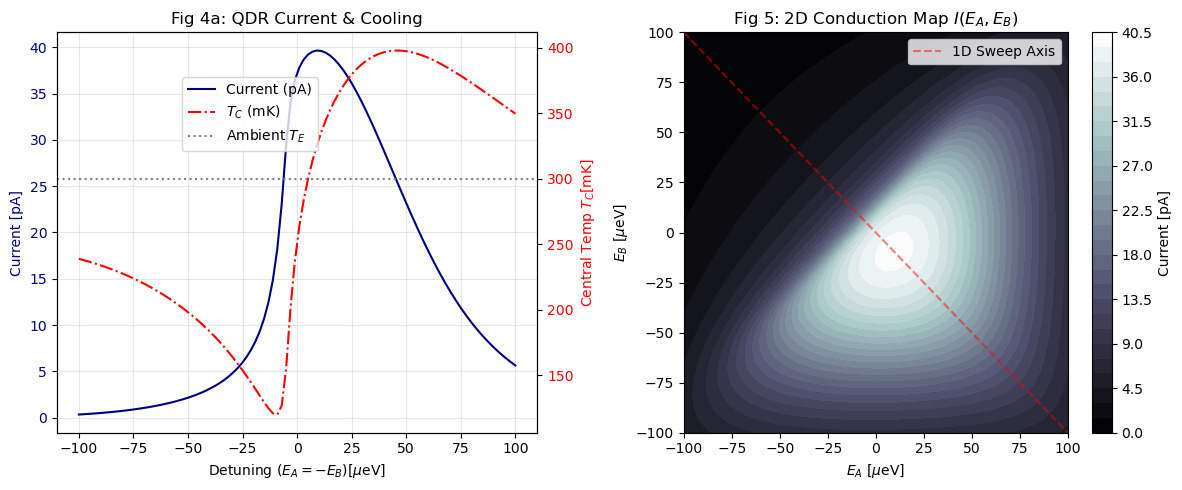

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import warnings

# Suppress warnings from root finder during extreme parameter probing
warnings.filterwarnings("ignore")

# --- 1. Physical Constants & Parameters ---
e = 1.602176634e-19    # Elementary charge (C)
kB_eV = 8.617333e-5    # Boltzmann constant (eV/K)
kB_J = 1.380649e-23    # Boltzmann constant (J/K)
L_0 = (kB_J**2 * np.pi**2) / (3 * e**2)

# Device parameters (Matching Fig 4 & 5)
T_E = 0.300            # Ambient Electron Temp (K)
T_L = 0.200            # Lattice Temp (K)
V_SD = 75e-6           # Source-Drain bias (V)
mu_S = V_SD / 2        # Source chemical potential (eV)
mu_D = -V_SD / 2       # Drain chemical potential (eV)

G_B = 80e-9            # Lorentzian tail background conductance (S)
A_area = 6.0           # 2DEG Area (um^2)
sigma = 40e-15         # e-phonon coupling (W/um^2/K^5)

I_0 = 120e-12          # Tunneling current scale factor (Amps) to match ~60pA peak

# --- 2. Core Physics Functions ---
def fermi(E, mu, T):
    """Fermi-Dirac distribution."""
    if T <= 0: return np.heaviside(mu - E, 0.5)
    # Clip exponent to prevent overflow in np.exp
    x = np.clip((E - mu) / (kB_eV * T), -100, 100)
    return 1.0 / (1.0 + np.exp(x))

def get_mu_C(E_A, E_B, T_C):
    """Solve for central chemical potential (mu_C) to enforce charge conservation (I_in = I_out)."""
    target = fermi(E_A, mu_S, T_E) + fermi(E_B, mu_D, T_E)
    def charge_diff(mu_C):
        return fermi(E_A, mu_C, T_C) + fermi(E_B, mu_C, T_C) - target
    try:
        # Search for mu_C between -100 ueV and +100 ueV
        return brentq(charge_diff, -100e-6, 100e-6)
    except ValueError:
        return 0.0

def get_I_and_Q(E_A, E_B, T_C):
    """Calculate steady state current and Quantum Dot Refrigerator cooling power."""
    mu_C = get_mu_C(E_A, E_B, T_C)
    # Current through Dot A (equal to Dot B by charge conservation)
    I = I_0 * (fermi(E_A, mu_S, T_E) - fermi(E_A, mu_C, T_C))
    
    # Heat flow into center: an electron brings E_A and leaves with E_B.
    # If E_A < E_B, Q_QDR is negative (Cooling). 
    Q_QDR = I * (E_A - E_B) 
    return I, Q_QDR, mu_C

def heat_balance(T_C, E_A, E_B):
    """Calculates net heat flow into the 2DEG. We want to find T_C where this is zero."""
    I, Q_QDR, mu_C = get_I_and_Q(E_A, E_B, T_C)
    
    T_bar = (T_E + T_C) / 2.0
    dT = T_C - T_E
    V_drop = V_SD / 2.0
    
    Q_B = -2 * G_B * (L_0 * T_bar * dT - (V_drop**2) / 2.0)
    Q_ep = A_area * sigma * (T_L**5 - T_C**5)
    
    return Q_QDR + Q_B + Q_ep

def solve_system(E_A, E_B):
    """Finds the steady state T_C and calculates final current."""
    def func(T_C):
        return heat_balance(T_C, E_A, E_B)
    try:
        # Look for a thermal equilibrium between 50 mK and 600 mK
        T_C_sol = brentq(func, 0.050, 0.600)
    except ValueError:
        T_C_sol = T_E  # Fallback if no cooling/heating is happening
        
    I_final, _, _ = get_I_and_Q(E_A, E_B, T_C_sol)
    return I_final, T_C_sol

# --- 3. Run Simulations ---

# Simulation 1: 1D sweep matching Fig 4(a) 
# E_A and E_B move in opposite directions
detuning = np.linspace(-100e-6, 100e-6, 100)
I_1D = np.zeros_like(detuning)
TC_1D = np.zeros_like(detuning)

print("Running 1D Sweep (Fig 4a representation)...")
for i, d in enumerate(detuning):
    E_A = d          
    E_B = -d         
    I_1D[i], TC_1D[i] = solve_system(E_A, E_B)

# Simulation 2: 2D map matching Fig 5
grid_pts = 60
EA_vec = np.linspace(-100e-6, 100e-6, grid_pts)
EB_vec = np.linspace(-100e-6, 100e-6, grid_pts)
I_2D = np.zeros((grid_pts, grid_pts))

print("Running 2D Map (Fig 5 representation)...")
for i, ea in enumerate(EA_vec):
    for j, eb in enumerate(EB_vec):
        I_final, _ = solve_system(ea, eb)
        # Only plot positive current (S -> D direction) as in the experiment
        I_2D[j, i] = max(0, I_final) 

# --- 4. Plotting Results ---
fig = plt.figure(figsize=(12, 5))

# Plot 1: 1D Asymmetric Current & Temperature (Fig 4a)
ax1 = fig.add_subplot(121)
ax1.plot(detuning * 1e6, I_1D * 1e12, color='navy', label='Current (pA)')
ax1.set_xlabel('Detuning ($E_A = -E_B$)[$\mu$eV]')
ax1.set_ylabel('Current [pA]', color='navy')
ax1.tick_params(axis='y', labelcolor='navy')
ax1.grid(True, alpha=0.3)

ax1_t = ax1.twinx()
ax1_t.plot(detuning * 1e6, TC_1D * 1000, color='red', linestyle='-.', label='$T_C$ (mK)')
ax1_t.set_ylabel('Central Temp $T_C$[mK]', color='red')
ax1_t.tick_params(axis='y', labelcolor='red')
ax1_t.axhline(T_E * 1000, color='gray', linestyle=':', label='Ambient $T_E$')
ax1.set_title('Fig 4a: QDR Current & Cooling')
fig.legend(loc="upper left", bbox_to_anchor=(0.15, 0.85))

# Plot 2: 2D Conduction Map (Fig 5)
ax2 = fig.add_subplot(122)
X, Y = np.meshgrid(EA_vec * 1e6, EB_vec * 1e6)
contour = ax2.contourf(X, Y, I_2D * 1e12, levels=30, cmap='bone')
plt.colorbar(contour, ax=ax2, label='Current [pA]')
ax2.plot([-100, 100], [100, -100], color='red', linestyle='--', alpha=0.5, label='1D Sweep Axis')
ax2.set_xlabel('$E_A$ [$\mu$eV]')
ax2.set_ylabel('$E_B$ [$\mu$eV]')
ax2.set_title('Fig 5: 2D Conduction Map $I(E_A, E_B)$')
ax2.legend()

plt.tight_layout()
plt.show()